In [1]:
import os
if os.path.basename(os.getcwd()) != "metro-flow-forecasting":
    os.chdir("metro-flow-forecasting")

import pandas as pd
import numpy as np
import joblib

# reload data + model
flow = pd.read_csv("data/processed/flow_features.csv", parse_dates=["interval"])
test = flow[flow["split"] == "test"].copy()

loaded = joblib.load("artifacts/metro_xgb_model.joblib")
model, FEATURES = loaded["model"], loaded["features"]

# predict and compute absolute error per row
test["pred"] = model.predict(test[FEATURES])
test["abs_err"] = (test["pred"] - test["inflow"]).abs()

print("Overall test MAE:", round(test["abs_err"].mean(), 2))

Overall test MAE: 25.75


In [2]:
def period(hour):
    if 7 <= hour <= 9:   return "morning_peak"
    if 17 <= hour <= 19: return "evening_peak"
    return "off_peak"

test["period"] = test["hour"].apply(period)

by_period = test.groupby("period").agg(
    mae=("abs_err", "mean"),
    avg_inflow=("inflow", "mean"),
    n=("abs_err", "size"),
).round(2)
print(by_period)

                mae  avg_inflow      n
period                                
evening_peak  36.40      324.46   4800
morning_peak  45.96      354.10   4800
off_peak      18.82      141.50  21362


In [3]:
station_avg = test.groupby("stationID")["inflow"].mean()
busy_stations = station_avg[station_avg >= station_avg.median()].index
test["station_type"] = np.where(test["stationID"].isin(busy_stations), "busy", "quiet")

by_station = test.groupby("station_type").agg(
    mae=("abs_err", "mean"),
    avg_inflow=("inflow", "mean"),
    n=("abs_err", "size"),
).round(2)
print(by_station)

                mae  avg_inflow      n
station_type                          
busy          34.01      295.32  15576
quiet         17.39      109.18  15386


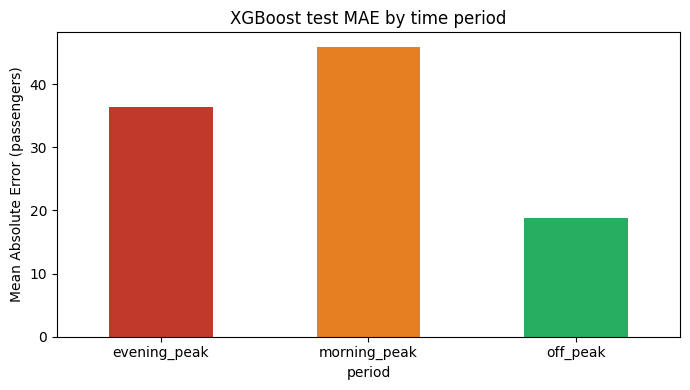

In [4]:
import matplotlib.pyplot as plt
by_period["mae"].plot(kind="bar", figsize=(7,4), color=["#c0392b","#e67e22","#27ae60"])
plt.title("XGBoost test MAE by time period")
plt.ylabel("Mean Absolute Error (passengers)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("reports/mae_by_period.png", dpi=120)  # save for the report
plt.show()